In [39]:
import pandas as pd
import matplotlib.pyplot as plt

print(pd.__version__)

df = pd.read_csv("../data/raw/train.csv")
df.head()

3.0.5


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [40]:
print("数据形状：", df.shape)
print("字段名称：", df.columns.tolist())

数据形状： (9800, 18)
字段名称： ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [42]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [43]:
print("缺失值：\n", df.isna().sum())
print("完全重复行：\n", df.duplicated().sum())
print("唯一订单数量：\n", df["Order ID"].nunique())

缺失值：
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
完全重复行：
 0
唯一订单数量：
 4922


In [44]:
#注意到日期形式为日/月/年，对其进行转换，并计算配送天数
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y", errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y", errors="coerce")

print("订单日期转换失败数量：", df["Order Date"].isna().sum())
print("配送日期转换失败数量：", df["Ship Date"].isna().sum())

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(df[["Order Date", "Ship Date", "Shipping Days"]].head())
print(df["Shipping Days"].describe())

订单日期转换失败数量： 0
配送日期转换失败数量： 0
  Order Date  Ship Date  Shipping Days
0 2017-11-08 2017-11-11              3
1 2017-11-08 2017-11-11              3
2 2017-06-12 2017-06-16              4
3 2016-10-11 2016-10-18              7
4 2016-10-11 2016-10-18              7
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64


In [45]:
#增加日期范围的检查
print("订单日期范围：", df["Order Date"].min(), "至", df["Order Date"].max())
print("配送日期范围：", df["Ship Date"].min(), "至", df["Ship Date"].max())

#检查主要字段的分布
print(df["Region"].value_counts())
print(df["Category"].value_counts())
print(df["Ship Mode"].value_counts())

订单日期范围： 2015-01-03 00:00:00 至 2018-12-30 00:00:00
配送日期范围： 2015-01-07 00:00:00 至 2019-01-05 00:00:00
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64
Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


## 项目目标

分析该超市的销售表现，识别销售增长趋势、重点地区和重点商品，
并提出基于数据的业务建议。

## 初步业务问题

- 1.销售额随时间如何变化？
- 2.哪些地区、州或城市贡献的销售额最高？
- 3.哪些品类、子品类和产品贡献的销售额最高？
- 4.不同客户群体和配送方式的销售表现有什么差异？
- 5.订单配送通常需要多长时间，不同配送方式是否存在差异？

## 项目限制

数据中没有Profit、Discount和Quantity 字段，所以本项目只分析销售额和订单表现，不分析利润、折扣以及销量。


## 数据初检记录

- 数据量：9800
- 字段数量：18
- 日期字段：Order Date,Ship Date
- 关键指标字段：
 - 'Sales':衡量销售金额
 - 'Order ID':用于计算订单数量，但不是直接求和
 - 'Customer ID':用于区分客户
 - 'Order Date':用于分析订单的时间趋势
 - 'Ship Date':与订单日期一同计算订单配送的时间
 - 'Region'、'State'、'City':用于比较不同地区的销售表现
 - 'Category'、'Sub-Category'、'Product Name':用于比较商品的销售表现
 - 'Segment':用于比较不同的客户群体
 - 'Ship Mode':用于比较不同配送方式
- 缺失值情况：Postal Code 字段中缺失了11行数据
- 重复行情况：无完全重复行
- 初步发现：<br>
 1.数据有9800行、18个字段。<br>
 2.'Order ID' 的唯一值数量少于总行数，说明同一订单可能存在多条商品的记录。<br>
 3.数据只有一个'Sales' 数值指标，所以后续分析重点是销售趋势、地区和商品结构，而不是盈利能力。<br>
 4.注意到订单日期和配送日期都是日/月/年形式，对其进行了转换，并计算出了配送天数，都在7天内完成订单的配送。

## 探索性分析

### 1. 月度销售趋势

In [46]:
#按月统计销售额，并查看月份的数据量
df["OrderMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = (df.groupby("OrderMonth", as_index=False)["Sales"]
                 .sum()
                 .sort_values("OrderMonth")
)

monthly_sales.head()

,OrderMonth,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [47]:
monthly_sales.tail()

,OrderMonth,Sales
43,2018-08,62837.8480
44,2018-09,86152.8880
45,2018-10,77448.1312
46,2018-11,117938.1550
47,2018-12,83030.3888


In [48]:
monthly_sales.shape

(48, 2)

In [49]:
#找出最高和最低的销售额月份
print("销售额最高的月份：", monthly_sales.loc[monthly_sales["Sales"].idxmax()])
print("销售额最低的月份：", monthly_sales.loc[monthly_sales["Sales"].idxmin()])


销售额最高的月份： OrderMonth       2018-11
Sales         117938.155
Name: 46, dtype: object
销售额最低的月份： OrderMonth     2015-02
Sales         4519.892
Name: 1, dtype: object


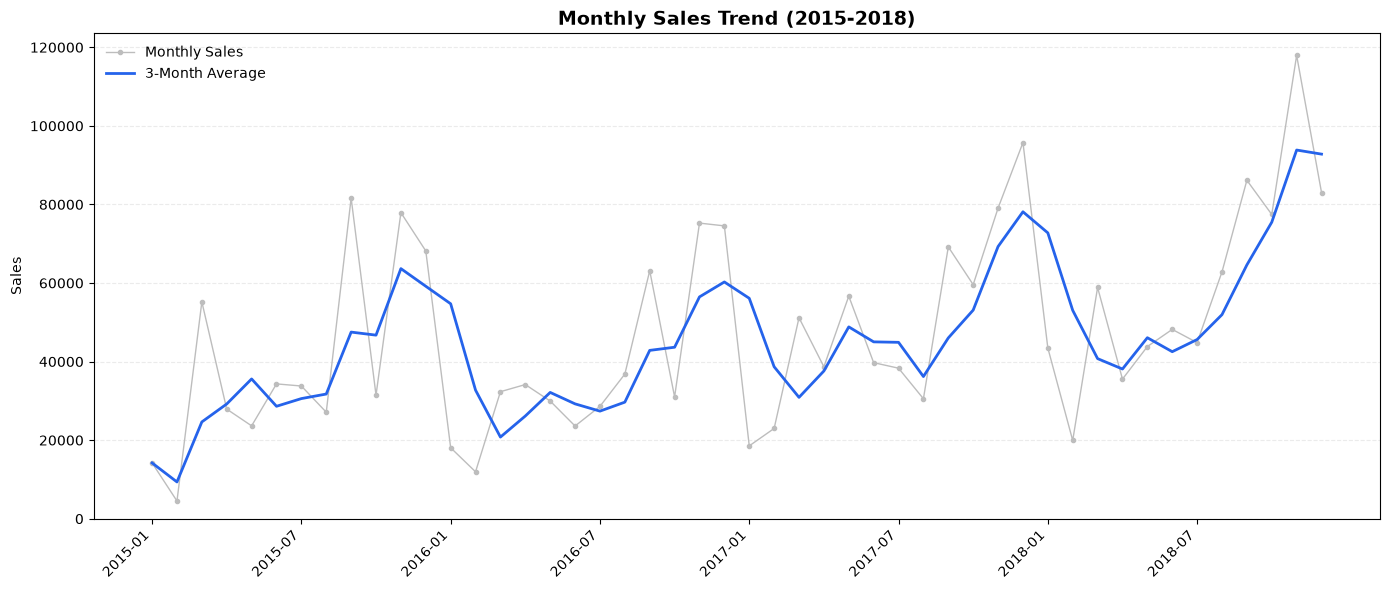

In [50]:
#画月度折线图
# 灰色线：每个月原始销售额
# 蓝色线：三个月的移动趋势
# 横轴每六个月显示一次

monthly_sales["Sales_3M"] = (
    monthly_sales["Sales"]
    .rolling(window=3, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 6))

#每个月原始销售额
ax.plot(
    monthly_sales["OrderMonth"],
    monthly_sales["Sales"],
    color="#bdbdbd",
    linewidth=1,
    marker="o",
    markersize=3,
    label="Monthly Sales"
)

#三个月移动平均
ax.plot(
    monthly_sales["OrderMonth"],
    monthly_sales["Sales_3M"],
    color="#2563eb",
    linewidth=2,
    label="3-Month Average"
)

#每六个月显示一个横轴标签
positions = list(range(0, len(monthly_sales), 6))
labels = monthly_sales.loc[positions]["OrderMonth"].tolist()

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_title("Monthly Sales Trend (2015-2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Sales")
ax.set_ylim(bottom=0)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.legend(loc="upper left",frameon=False)

fig.tight_layout()
fig.savefig("../images/monthly_sales.png", dpi=180, bbox_inches="tight")

plt.show()

#### 月度销售趋势观察

- 数据覆盖的月份范围是：2015-01 至 2018-12。
- 销售额最高的月份是 2018-11 ，销售额为117938.155。
- 销售额最低的月份是 2015-02 ，销售额为4519.892。
- 整体月度销售呈波动上升趋势。
- 灰色线表示每月原始销售额，波动明显。
- 蓝色线表示三个月平均销售额，整体呈现波动上升趋势。
- 2018年的销售水平整体高于2015年。
- 当前数据无法解释销售额变化的原因，因为没有促销、成本、市场活动等字段，无法分析得知。

### 2. 地区销售表现

#### 地区销售总额比较

In [51]:
#按地区统计销售额，并按照销售额降序排列
region_sales = (
    df.groupby("Region",as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

#计算各地区销售额占总销售额的百分比
region_sales["SalesSharePct"] = (
    region_sales["Sales"]
    / region_sales["Sales"].sum()
    * 100
).round(2)

region_sales


,Region,Sales,SalesSharePct
3,West,710219.6845,31.40
1,East,669518.7260,29.60
0,Central,492646.9132,21.78
2,South,389151.4590,17.21


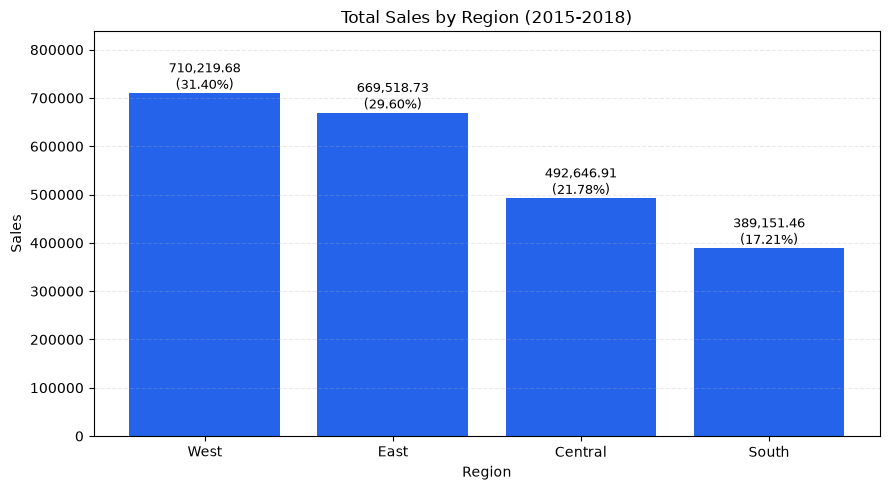

In [52]:
#画出各地区的销售额柱状图

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    region_sales["Region"],
    region_sales["Sales"],
    color="#2563eb"
)

for bar, sales, share in zip(
    bars,
    region_sales["Sales"],
    region_sales["SalesSharePct"]
):
    #将销售额和百分比写在柱子正上方
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{sales:,.2f}\n({share:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Total Sales by Region (2015-2018)")
ax.set_xlabel("Region")
ax.set_ylabel("Sales")

#给柱子顶部留出空间，避免数字被图片边界裁掉
ax.set_ylim(0, region_sales["Sales"].max() * 1.18)

ax.grid(axis="y", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/region_sales.png", dpi=180, bbox_inches="tight")

plt.show()

#### 地区销售总额观察

- West 的销售额最高,为 710219.68,占总销售额的 31.40%。
- East 排名第二,为 669518.73,占总销售额的 29.60%。
- Central 的销售额为 492646.91,占总销售额的 21.78%。
- South 的销售额最低,为 389151.46,占总销售额的 17.21%。
- West 和 East 两地销售额占总销售额的约 61%,是主要的销售地区。
- 数据中没有利润字段,所以分析各地区的销售总额,不能判断各地区是否是最赚钱的。 

### 3. 品类和子品类表现

#### 3.1 品类销售总额

In [53]:
#计算品类销售额和占比
category_sales = (
    df.groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_sales["SharePct"] = (
    category_sales["Sales"] / category_sales["Sales"].sum() * 100
).round(2)

category_sales

,Category,Sales,SharePct
2,Technology,827455.8730,36.59
0,Furniture,728658.5757,32.22
1,Office Supplies,705422.3340,31.19


#### 3.2 子品类销售额排名

In [54]:
subcategory_sales = (
    df.groupby(["Category", "Sub-Category"], as_index=False)["Sales"]
    .sum()
)

subcategory_sales["SharePct"] = (
    subcategory_sales["Sales"] / subcategory_sales["Sales"].sum() * 100
).round(2)

#取出子品类销售额最高的前10名，并根据sales降序排列
top10_subcategory_sales = (
    subcategory_sales.nlargest(10, "Sales")
    .sort_values("Sales", ascending=False)
)

top10_subcategory_sales

,Category,Sub-Category,Sales,SharePct
16,Technology,Phones,327782.4480,14.49
1,Furniture,Chairs,322822.7310,14.27
11,Office Supplies,Storage,219343.3920,9.70
3,Furniture,Tables,202810.6280,8.97
6,Office Supplies,Binders,200028.7850,8.84
15,Technology,Machines,189238.6310,8.37
13,Technology,Accessories,164186.7000,7.26
14,Technology,Copiers,146248.0940,6.47
0,Furniture,Bookcases,113813.1987,5.03
4,Office Supplies,Appliances,104618.4030,4.63


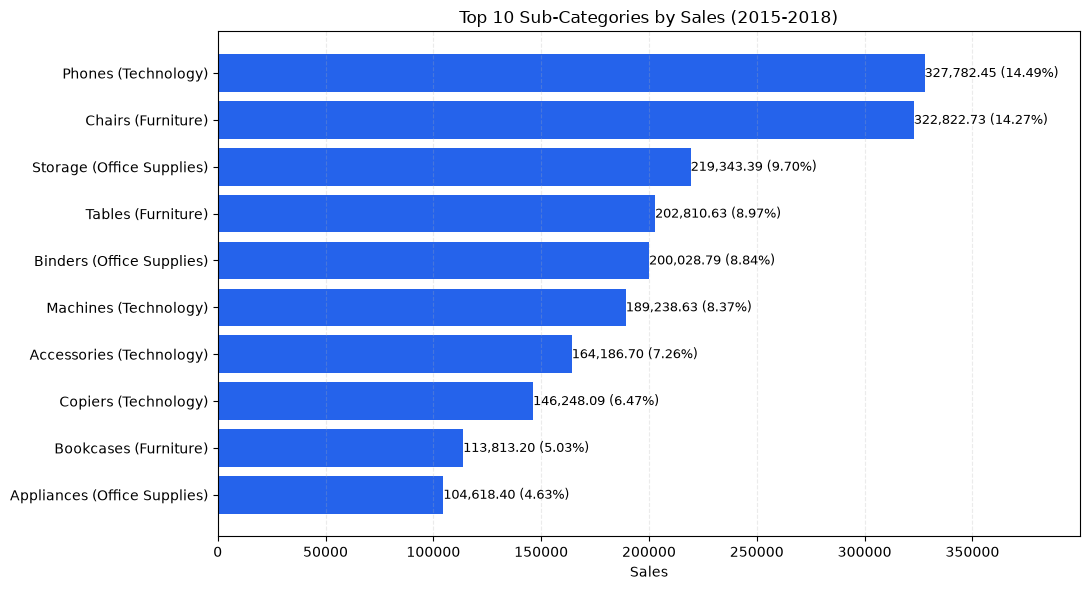

In [55]:
#画子品类销售额前10名的水平柱状图
fig, ax = plt.subplots(figsize=(11, 6))

top10_labels = [
    f"{sub_category} ({category})"
    for sub_category, category in zip(
        top10_subcategory_sales["Sub-Category"],
        top10_subcategory_sales["Category"]
    )
]

bars = ax.barh(
    top10_labels,
    top10_subcategory_sales["Sales"],
    color="#2563eb"
)

for bar, sales, share in zip(
    bars,
    top10_subcategory_sales["Sales"],
    top10_subcategory_sales["SharePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{sales:,.2f} ({share:.2f}%)",
        ha="left",
        va="center",
        fontsize=9
    )

ax.invert_yaxis()

ax.set_title("Top 10 Sub-Categories by Sales (2015-2018)")
ax.set_xlabel("Sales")
ax.set_ylabel("")
ax.set_xlim(0, top10_subcategory_sales["Sales"].max() * 1.22)

ax.grid(axis="x", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/top10-subcategory_sales.png",dpi=180,bbox_inches="tight")

plt.show()

#### 品类和子品类的销售观察

- Technology 是销售额最高的品类，销售额为 827455.87，占总销售额 36.59%。
- Furniture 排名第二，为 728658.58，占 32.22%。
- Office Supplies 排名第三，为 705422.33，占 31.19%。
- 三个品类的销售额占比相近，没有品类占绝对的优势。
- Phones 是销售额最高的子品类，为 327782.45，占 14.49%。
- Chairs 排名第二，为322822.73，占 14.27%。
- 排名前十的子品类中，Technology 和 Furniture 占大多数。
- 当前数据没有利润字段，只能判断销售规模，不能判断各品类的利润情况。

### 4. 产品与客户表现

#### 4.1 产品销售额排名

In [56]:
#汇总每个产品的销售额以及占比
product_sales = (
    df.groupby(
        ["Product ID", "Product Name", "Category"],
        as_index=False
    )["Sales"]
    .sum()
)

product_sales["SharePct"] = (
    product_sales["Sales"] / product_sales["Sales"].sum() * 100
).round(3)

#按降序输出前10个产品的销售额
top10_products = (
    product_sales.nlargest(10, "Sales")
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

top10_products

,Product ID,Product Name,Category,Sales,SharePct
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,61599.824,2.724
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.384,1.214
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,1.001
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.576,0.967
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.479,0.877
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.500,0.841
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,18839.686,0.833
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.895,0.812
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.068,0.794
9,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,17030.312,0.753


In [57]:
top10_product_share = (
    top10_products["Sales"].sum()
    / product_sales["Sales"].sum()
)

print(f"前10名产品销售额占比：{top10_product_share:.2%}")

前10名产品销售额占比：10.82%


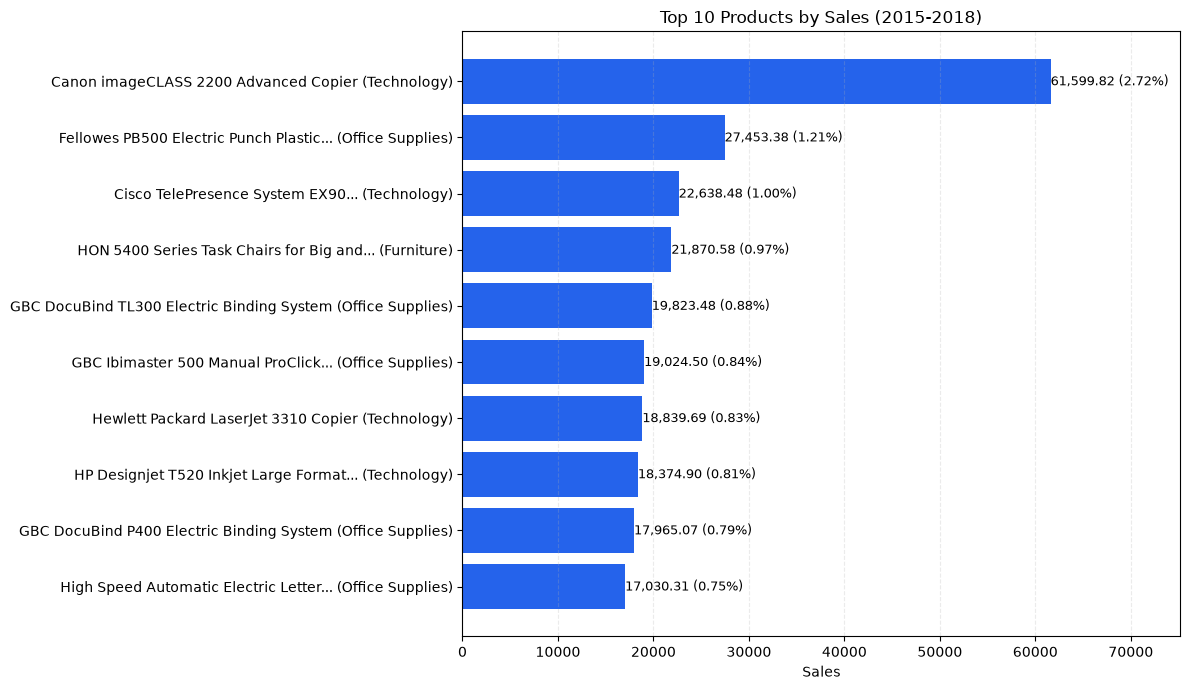

In [58]:
#画出产品销售额前10名
#因为产品名称较长，直接放到坐标轴上会产生拥挤，所以先缩短名称，完整名称仍保留在表格里

from textwrap import shorten

top10_products["ShortName"] = top10_products["Product Name"].apply(
    lambda name: shorten(
        name,
        width=42,
        placeholder="..."
    )
)

product_labels = [
    f"{short_name} ({category})"
    for short_name, category in zip(
        top10_products["ShortName"],
        top10_products["Category"]
    )
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    product_labels,
    top10_products["Sales"],
    color="#2563eb"
)

for bar, sales, share in zip(
    bars,
    top10_products["Sales"],
    top10_products["SharePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{sales:,.2f} ({share:.2f}%)",
        ha="left",
        va="center",
        fontsize=9
    )

ax.invert_yaxis()

ax.set_title("Top 10 Products by Sales (2015-2018)")
ax.set_xlabel("Sales")
ax.set_ylabel("")
ax.set_xlim(0, top10_products["Sales"].max() * 1.22)

ax.grid(axis="x", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/top10_products.png", dpi=180, bbox_inches="tight")

plt.show()

#### 产品销售额观察

- Canon imageCLASS 2200 Advanced Copier 是销售额最高的产品，销售额为 61599.82，占总销售额的 2.72%。
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine 排名第二，销售额为 27453.38，占总销售额的 1.21%。
- Cisco TelePresence System EX90 Videoconferencing Unit 排名第三，销售额为 22638.48，占总销售额的 1.00%。
- 前10名产品的销售总额合计约占总销售额的 10.82%。
- 单个产品占总销售额的比例都很低，说明销售额分布在较多产品中，没有单一产品占据绝对优势。
- 前10名产品来自Technology, Office Supplies, Furniture，其中Technology和Office Supplies 的产品占大多数。
- 当前数据没有利润字段，无法判断产品的盈利能力，只能判断该产品的销售额。

#### 4.2 客户销售额排名

In [59]:
#汇总每位客户的销售额和占比
customer_sales = (
    df.groupby(
        ["Customer ID", "Customer Name", "Segment"],
        as_index=False
    )["Sales"]
    .sum()
)

customer_sales["SharePct"] = (
    customer_sales["Sales"] / customer_sales["Sales"].sum() * 100
).round(3)

top10_customers = (
    customer_sales.nlargest(10, "Sales")
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

top10_customers


,Customer ID,Customer Name,Segment,Sales,SharePct
0,SM-20320,Sean Miller,Home Office,25043.050,1.107
1,TC-20980,Tamara Chand,Corporate,19052.218,0.842
2,RB-19360,Raymond Buch,Consumer,15117.339,0.668
3,TA-21385,Tom Ashbrook,Home Office,14595.620,0.645
4,AB-10105,Adrian Barton,Consumer,14473.571,0.640
5,KL-16645,Ken Lonsdale,Consumer,14175.229,0.627
6,SC-20095,Sanjit Chand,Consumer,14142.334,0.625
7,HL-15040,Hunter Lopez,Consumer,12873.298,0.569
8,SE-20110,Sanjit Engle,Consumer,12209.438,0.540
9,CC-12370,Christopher Conant,Consumer,12129.072,0.536


In [60]:
#计算前10名客户的总占比
top10_customer_share = (
    top10_customers["Sales"].sum() / customer_sales["Sales"].sum()
)

print(f"前10名客户的销售额总占比:{top10_customer_share:.2%}")

前10名客户的销售额总占比:6.80%


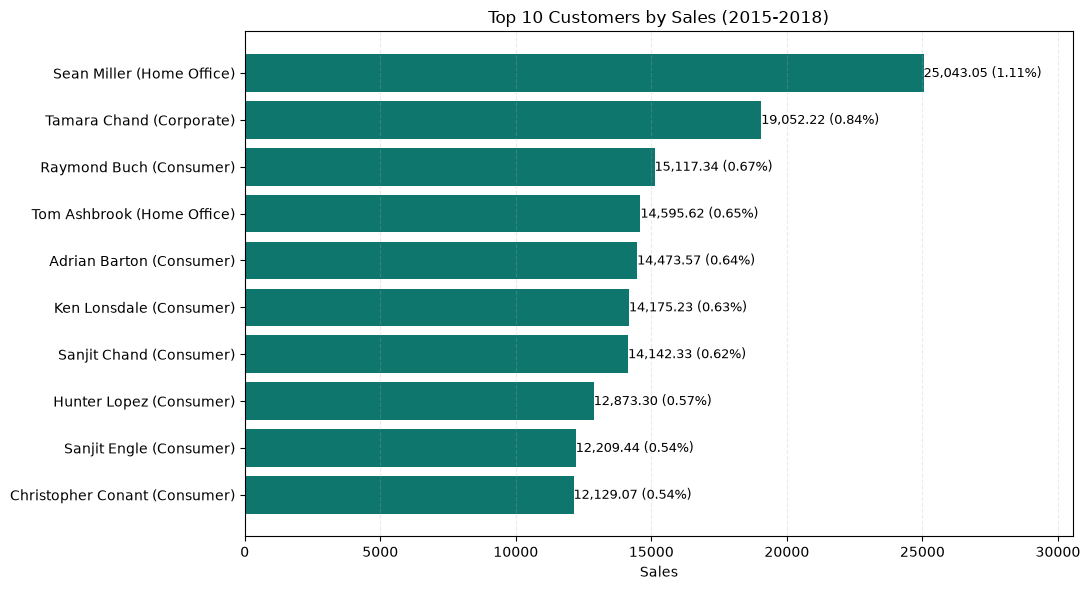

In [61]:
#画客户销售额前10名
customer_labels = [
    f"{name} ({segment})"
    for name, segment in zip(
        top10_customers["Customer Name"],
        top10_customers["Segment"]
    )
]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    customer_labels,
    top10_customers["Sales"],
    color="#0f766e"
)

for bar, sales, share in zip(
    bars,
    top10_customers["Sales"],
    top10_customers["SharePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{sales:,.2f} ({share:.2f}%)",
        ha="left",
        va="center",
        fontsize=9
    )

ax.invert_yaxis()

ax.set_title("Top 10 Customers by Sales (2015-2018)")
ax.set_xlabel("Sales")
ax.set_ylabel("")
ax.set_xlim(0, top10_customers["Sales"].max() * 1.22)

ax.grid(axis="x", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/top10_customers.png", dpi=180, bbox_inches="tight")

plt.show()

In [62]:
print("customer_sales 客户行数：", len(customer_sales))

customer_sales 客户行数： 793


#### 客户销售额观察

- Sean Miller 是销售额最高的用户，销售额为 25043.05，占总销售额的 1.11%。
- Tamara Chand 排名第二，销售额为 19052.22，占 0.84%。
- Raymond Buch 排名第三，销售额为 15117.34，占 0.67%。
- 前10名客户销售额合计占总销售额的 6.80%。
- 单一客户销售额占比均低于 1.2%，说明销售没有集中在极少数客户手中。
- 前10名客户中，Consumer 占7位，Home Office 占2位，而Corporate 占1位。
- 数据集中包含793 位唯一客户，销售额分布在较多客户中。
- 当前数据没有利润字段，只能判断客户对销售额的贡献程度。

#### 4.3 客户群体销售表现

In [63]:
#汇总客户群体指标
segment_summary = (
    df.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID","nunique")
    )
    .reset_index()
)

segment_summary["SalesSharePct"] = (
    segment_summary["Sales"] / segment_summary["Sales"].sum() * 100
).round(2)

segment_summary["AvgSalesPerOrder"] = (
    segment_summary["Sales"]  / segment_summary["Orders"]
).round(2)

segment_summary = (
    segment_summary
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

segment_summary


,Segment,Sales,Orders,Customers,SalesSharePct,AvgSalesPerOrder
0,Consumer,1.148061e+06,2537,409,50.76,452.53
1,Corporate,6.884941e+05,1491,236,30.44,461.77
2,Home Office,4.249822e+05,894,148,18.79,475.37


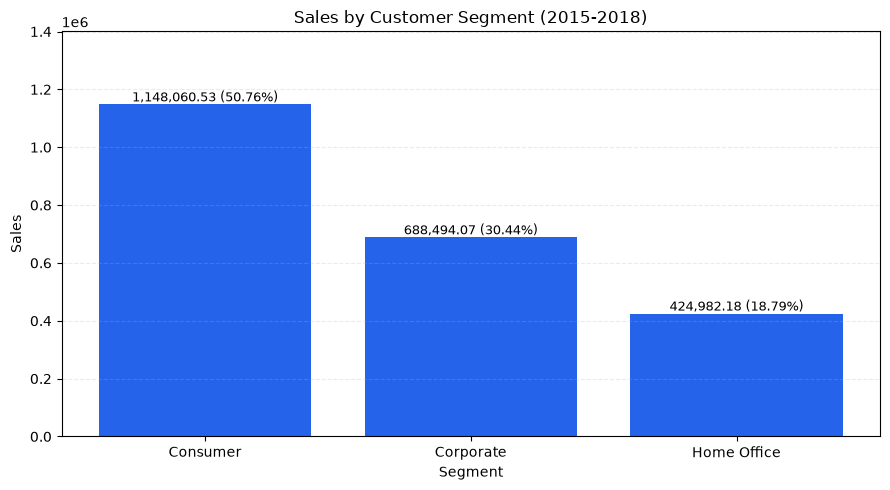

In [64]:
#画客户群体销售额柱状图
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    segment_summary["Segment"],
    segment_summary["Sales"],
    color="#2563eb" 
)

for bar, sales, share in zip(
    bars,
    segment_summary["Sales"],
    segment_summary["SalesSharePct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{sales:,.2f} ({share:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Sales by Customer Segment (2015-2018)")
ax.set_xlabel("Segment")
ax.set_ylabel("Sales")
ax.set_ylim(0, segment_summary["Sales"].max() * 1.22)

ax.grid(axis="y", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/sales_by_segment.png", dpi=180, bbox_inches="tight")

plt.show()

#### 客户群体销售观察

- Consumer 是销售额最高的客户群体，销售额为 1148060.53，占总销售额的 50.76%。
- Corporate 排名第二，销售额为 688494.07，占 30.44%。
- Home Office 排名第三，销售额为 424982.18，占 18.79%。
- Consumer 的订单数量为 2537，客户数量为 409，均高于其他两个群体。
- Consumer 的销售额最高，主要因为订单数量和客户数量较高。
- Corporate 的单均销售额为 461.77，高于 Consumer 的 452.53。
- Home Office 的单均销售额为 475.37，是三个群体中最高的。
- 三个群体的单均销售额相近，都处于 452.53 - 475.37之间，差距较小。
- 当前数据没有利润字段，无法判断哪个群体盈利能力最强，只能比较销售额和订单结构。

### 5. 配送方式与配送天数

#### 5.1 配送方式销售和时效比较

In [65]:
#汇总配送方式指标
ship_mode_summary = (
    df.groupby("Ship Mode")
    .agg(
        Sales=("Sales", "sum"),
        Orders=("Order ID", "nunique"),
        AvgShippingDays=("Shipping Days", "mean"),
        MedianShippingDays=("Shipping Days", "median")
    )
    .reset_index()
)

ship_mode_summary["SalesSharePct"] = (
    ship_mode_summary["Sales"] / ship_mode_summary["Sales"].sum() * 100
).round(2)

ship_mode_summary["AvgSalesPerOrder"] = (
    ship_mode_summary["Sales"] / ship_mode_summary["Orders"]
).round(2)

ship_mode_summary["AvgShippingDays"] = (
    ship_mode_summary["AvgShippingDays"].round(2)
)

ship_mode_summary = (
    ship_mode_summary
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

ship_mode_summary

,Ship Mode,Sales,Orders,AvgShippingDays,MedianShippingDays,SalesSharePct,AvgSalesPerOrder
0,Standard Class,1.340831e+06,2945,5.01,5.0,59.29,455.29
1,Second Class,4.499142e+05,944,3.25,3.0,19.89,476.60
2,First Class,3.455723e+05,772,2.18,2.0,15.28,447.63
3,Same Day,1.252190e+05,261,0.04,0.0,5.54,479.77


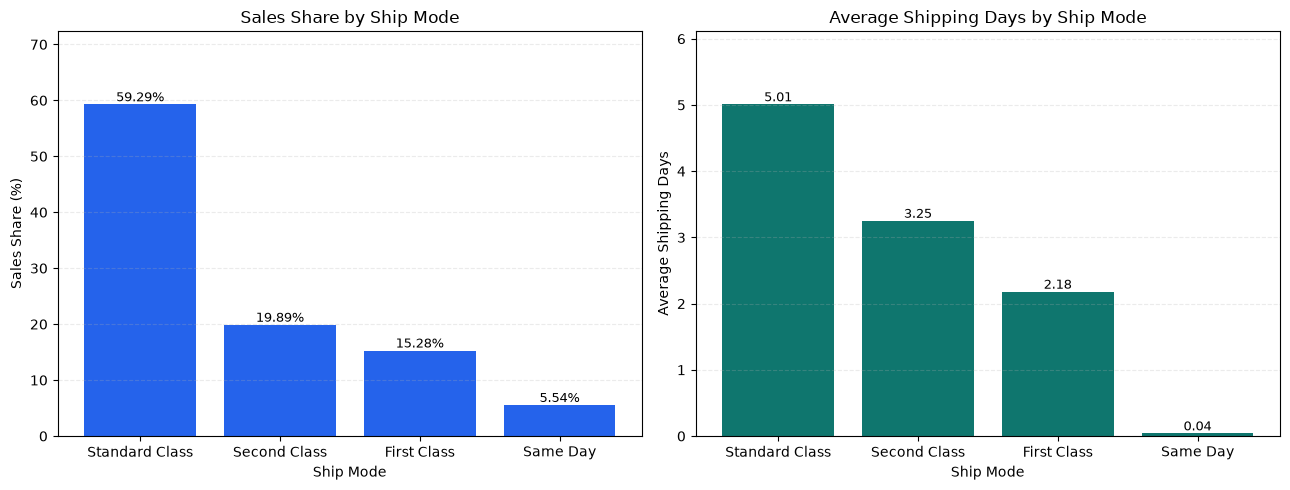

In [66]:
#画配送方式组合图
fig,axes = plt.subplots(1, 2, figsize=(13,5))

#左图：不同配送方式的销售额占比
bars_sales = axes[0].bar(
    ship_mode_summary["Ship Mode"],
    ship_mode_summary["SalesSharePct"],
    color="#2563eb"
)

for bar,share in zip(
    bars_sales,
    ship_mode_summary["SalesSharePct"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{share:.2f}%",
        ha="center",
        va="bottom", 
        fontsize=9
    )

axes[0].set_title("Sales Share by Ship Mode")
axes[0].set_xlabel("Ship Mode")
axes[0].set_ylabel("Sales Share (%)")
axes[0].set_ylim(0, ship_mode_summary["SalesSharePct"].max() * 1.22)
axes[0].grid(axis="y", linestyle="--", alpha=0.25)

#右图：不同配送方式的平均配送天数
bars_days = axes[1].bar(
    ship_mode_summary["Ship Mode"],
    ship_mode_summary["AvgShippingDays"],
    color="#0f766e"
)

for bar,days in zip(
    bars_days,
    ship_mode_summary["AvgShippingDays"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{days:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

axes[1].set_title("Average Shipping Days by Ship Mode")
axes[1].set_xlabel("Ship Mode")
axes[1].set_ylabel("Average Shipping Days")
axes[1].set_ylim(0, ship_mode_summary["AvgShippingDays"].max() * 1.22)
axes[1].grid(axis="y", linestyle="--", alpha=0.25)

fig.tight_layout()
fig.savefig("../images/shipping_mode_summary.png", dpi=180, bbox_inches="tight")

plt.show()




#### 配送方式销售和时效观察

- Standard Class 是销售额最高的配送方式，销售额为 1340831.31，占 59.29%。
- Second Class 排名第二，销售额为 449914.18，占 19.89%。
- First Class 排名第三，销售额为 345572.26，占 15.28%。
- Same Day 排名第四，销售额为 125219.04，占5.54%，是占比最低的配送方式。
- Standard Class 的订单数量为 2945，远高于其他配送方式。
- 不同配送方式的单均销售额差距较小，都在 447.63 至 479.77之间。
- Standard Class 的销售额占比最高，主要是因为订单数量多，而不是因为单均销售额高。
- 配送方式的速度由快到慢为：Same Day、First Class、Second Class、Standard Class。
- Same Day 的平均配送时间仅有 0.04 天，中位数为0，说明大多数都是当天送达。
- Standard Class 的平均配送天数为 5.01，配送时间最长。
- 当前字段没有利润，无法判断哪个配送方式盈利能力更强。

### 6. 地区与品类交叉分析
#### 地区品类销售结构

In [67]:
#计算地区与品类交叉表
region_category_sales = df.pivot_table(
    index="Region",
    columns="Category",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)

region_category_share = (
    region_category_sales
    .div(region_category_sales.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

region_category_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


In [68]:
region_category_share

Category,Furniture,Office Supplies,Technology
Region,,,
Central,32.54,33.21,34.25
East,30.84,29.86,39.30
South,29.95,31.97,38.08
West,34.55,30.62,34.83


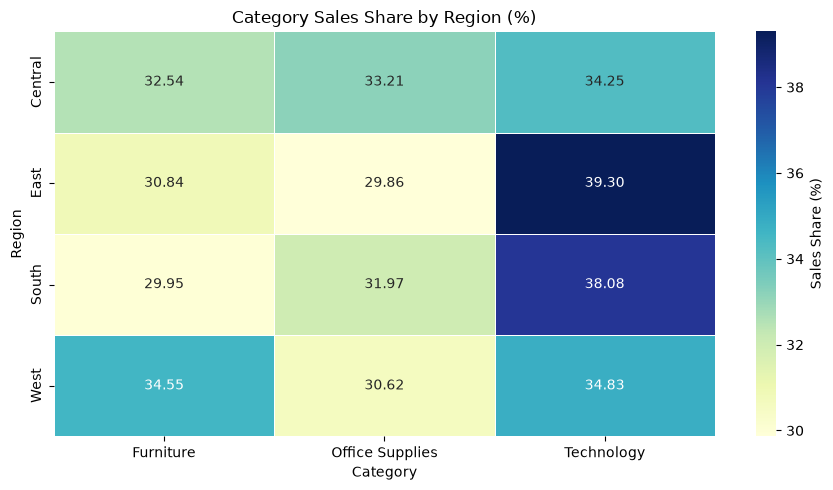

In [69]:
#画地区品类占比热力图
import seaborn as sns

fig, ax = plt.subplots(figsize=(9,5))

sns.heatmap(
    region_category_share,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Sales Share (%)"},
    ax=ax
)

ax.set_title("Category Sales Share by Region (%)")
ax.set_xlabel("Category")
ax.set_ylabel("Region")

fig.tight_layout()
fig.savefig("../images/region_category_share.png", dpi=180, bbox_inches="tight")

plt.show()

#### 地区品类结构观察

- East 的 Technology的销售占比为 39.30%，是各地区品类占比中最高的一项。
- South 的 Technology的销售占比为 38.30%，高于 Furniture 和 Office Supplies。
- Central 的三个品类占比相近，分别是 Furniture：32.54%，Office Supplies ：33.21%，Technology：34.25%。
- West 的 Technology的销售额占比最高，占 34.83%，并且Furniture 与Technology 两类销售额非常相近。
- 在 South 和 East 两地比较偏向 Technology，而 West 的 Furniture 销售占比高于其他地区；不过 West 的 Technology 和 Furniture 占比非常接近。
- 各个地区都存在三个品类的销售，说明品类结构有差异，但没有某个地区完全依赖单一品类。
- 当前数据没有利润字段，所以只能分析销售结构，不能判断不同地区品类组合的盈利能力。

## 综合结论与发现

### 核心发现

#### 1. 销售趋势

- 2015 至 2018 年间，销售额整体呈现波动上升趋势。
- 2018年11月的销售额最高，为 117938.155，2015年2月销售额最低，为 4519.892。
- 月度销售额波动明显，但三个月平均线显示整体趋势向上。

#### 2. 地区和品类销售

- West 是销售额最高的地区，占 31.40%，South 最低，占 17.21%。
- West 和 East两地合计贡献了约 61% 的销售额。
- Technology 是销售额最高的品类，占 36.59%，Furniture 占 32.22%，Office Supplies 占 31.19%。
- 三个品类的销售占比都较相近，没有单一品类占据绝对优势。
- Phones 和 Chairs 是销售额最高的两个子品类，分别占 14.49% 和 14.27%。

#### 3. 产品和客户集中度

- 前10名产品的销售额合计约占总销售额的 10.82%。
- 前10名客户的销售额合计约占总销售额的 6.80%。
- 销售额分布在较多产品和客户中，没有明显依赖少数产品或客户。
- 数据集中包含了 793 位唯一的客户。

#### 4. 客户群体

- Consumer 是销售额最高的客户群体，占 50.76%。
- Corporate 占 30.44%，Home Office 占 18.79%。
- Consumer 的订单数量和客户数量都最多。
- Home Office 的单均销售额最高，为 475.37。
- 三个客户群体的单均销售额差距较小。

#### 5. 配送方式

- Standard Class 是销售额占比最高的配送方式，占 59.29%。
- Standard Class 的平均配送天数为 5.01 天，是四种配送方式中最长的。
- Same Day 的销售额占 5.54%，平均配送天数为 0.04天，中位数为0，说明大多数是当天送达的。
- 不同配送方式的单均销售额差距较小。

#### 6. 地区与品类交叉结构

- East 和 South 的 Technology 销售占比高，分别为 39.30% 和 38.08%。
- West 的 Furniture 销售额占比为 34.55%，是该地区占比最高的品类。
- Central 三个品类的销售额占比都在 32% 至 35% 之间，结构较均衡。
- 各地区品类结构存在差异，没有地区完全依赖某一单一品类。

### 业务建议

1. 保持品类结构平衡，同时关注重点子品类
Technology、Furniture、Office Supplies 的销售额占比接近。销售层面可以优先关注表现较优异的子品类：Phones、Chairs、Storage 等，但不能判断它们的盈利能力。

2. 针对不同地区采用不同的品类重点
East 和 South 的 Technology 占比最高，West 的 Furniture 占比更高，Central 的品类结构较均衡。可以根据地区差异调整商品陈列、库存和推广重点，但需要成本数据等来进一步验证。

3. 维护 Consumer 客户群体，同时观察 Corporate 和 Home Office
Consumer 贡献了约一半以上销售额，是主要的销售来源。Corporate 和 Home Office 的单均销售额略高，可以考虑进一步研究其偏好和购物习惯等。

4. 评估配送速度与订单规模的平衡
Standard Class 贡献了大部分的销售额和订单，但平均配送时间最长。Same Day 的销售占比较低，需要结合配送成本才能判断是否扩大服务范围。

5. 补充利润和成本数据再制定盈利策略
当前数据只有销售额，没有利润、成本、折扣等字段，因此所有建议只能从销售规模和订单结构角度出发。

### 项目限制

- 数据只包含销售额，没有 Profit、Cost、Discount、Quantity、Returns 等字段。
- 无法分析利润率、成本效率、折扣影响和退货情况。
- 无法判断哪种产品、客户群体或配送方式的盈利能力最强。
- 观察到的地区、品类和配送差异是相关性描述，不能直接解释为因果关系。
- 数据覆盖时间为 2015-2018，无法直接代表更晚时期的业务表现。

### 后续改进

- 补充利润和成本字段，计算利润率。
- 补充折扣和退货字段，计算促销与退货对销售的影响。
- 对客户进行分群和复购分析，研究客户生命周期。
- 评估不同配送方式的成本和时效。
- 在数据质量稳定后，尝试销售额预测和情景分析。